In [1]:
import xarray as xr


dt = xr.open_dataset("/glade/derecho/scratch/bgong/amip_s2s_ensembles/20190502/ensemble_20190502_seed0.nc")

In [2]:
dt["PRATEsfc_24h"]

<xarray.DataArray 'PRATEsfc_24h' (member: 4, time: 46, lat: 180, lon: 360)> Size: 48MB
[11923200 values with dtype=float32]
Coordinates:
  * member   (member) int32 16B 0 1 2 3
  * time     (time) datetime64[ns] 368B 2019-05-02 2019-05-03 ... 2019-06-16
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

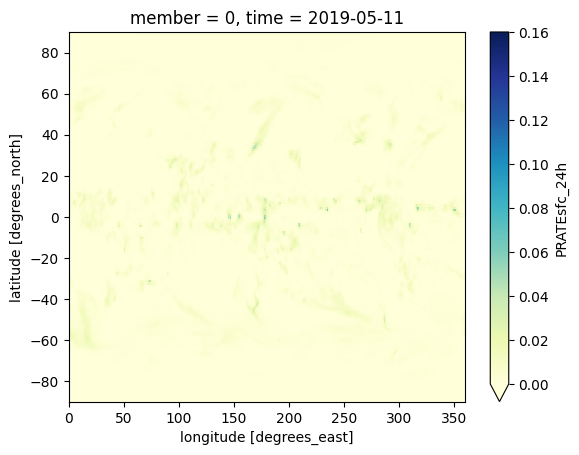

In [22]:
(dt["PRATEsfc_24h"] * 24 * 3.6).isel(time=9, member=0).plot(cmap="YlGnBu",vmin=0, vmax=0.16)

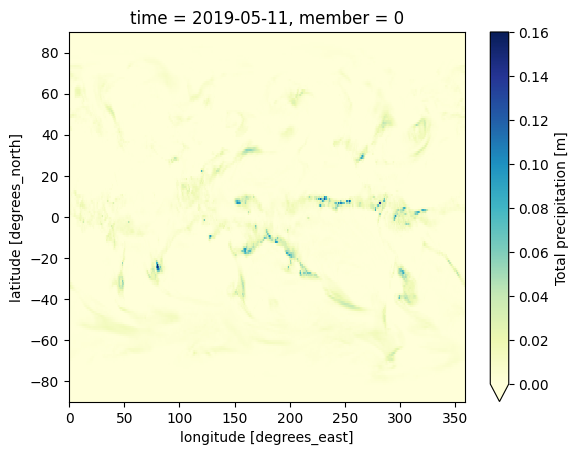

In [23]:
time = dt["PRATEsfc_24h"].isel(time=9, member=0)["time"]
era5["total_precipitation_24hr"].sel(time=time).plot(cmap="YlGnBu",vmin=0, vmax=0.16)

In [10]:
time

<xarray.DataArray 'time' ()> Size: 8B
array('2019-05-11T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    member   int32 4B 0
    time     datetime64[ns] 8B 2019-05-11

In [11]:
variable = "total_precipitation_24hr"
variable_fcst = "PRATEsfc_24h"
era5 = xr.open_mfdataset(
    f"/glade/derecho/scratch/bgong/era5/{variable}/*_180x360.nc",
    chunks={},
    engine="netcdf4",
).rename({"lat": "latitude", "lon": "longitude"})

In [ ]:
era5.max()


<xarray.Dataset> Size: 4B
Dimensions:                   ()
Data variables:
    total_precipitation_24hr  float32 4B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.5.0 (https://...
    Conventions:               CF-1.6
    last_updated:              2025-08-05 01:44:46.855276+00:00
    valid_time_start:          1940-01-01
    valid_time_stop:           2025-04-30
    valid_time_stop_era5t:     2025-07-30
    history:                   Tue Aug 05 12:10:58 2025: cdo -P 80 remapcon,r...
    CDO:                       Climate Data Operators version 2.5.0 (https://...
    cdo_openmp_thread_number:  80

In [12]:
era5 = era5.rename({"latitude": "lat", "longitude": "lon"})

In [13]:
era5["total_precipitation_24hr"].sel(time=time).max().values

array(0.15207912, dtype=float32)

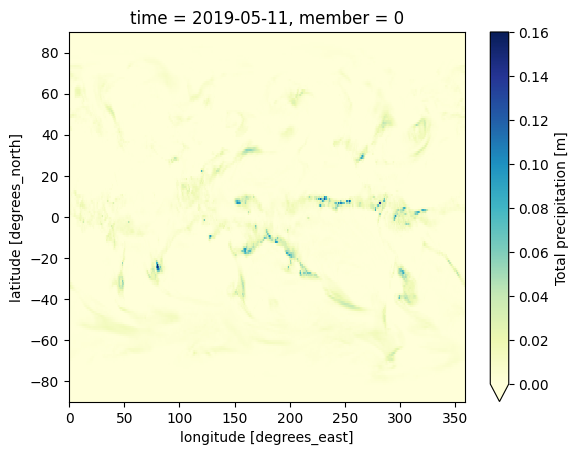

In [14]:
era5["total_precipitation_24hr"].sel(time=time).plot(cmap="YlGnBu",vmin=0, vmax=0.16)

In [73]:
era5["total_precipitation_24hr"].sel(time=time).max().values


array(0.15207912, dtype=float32)

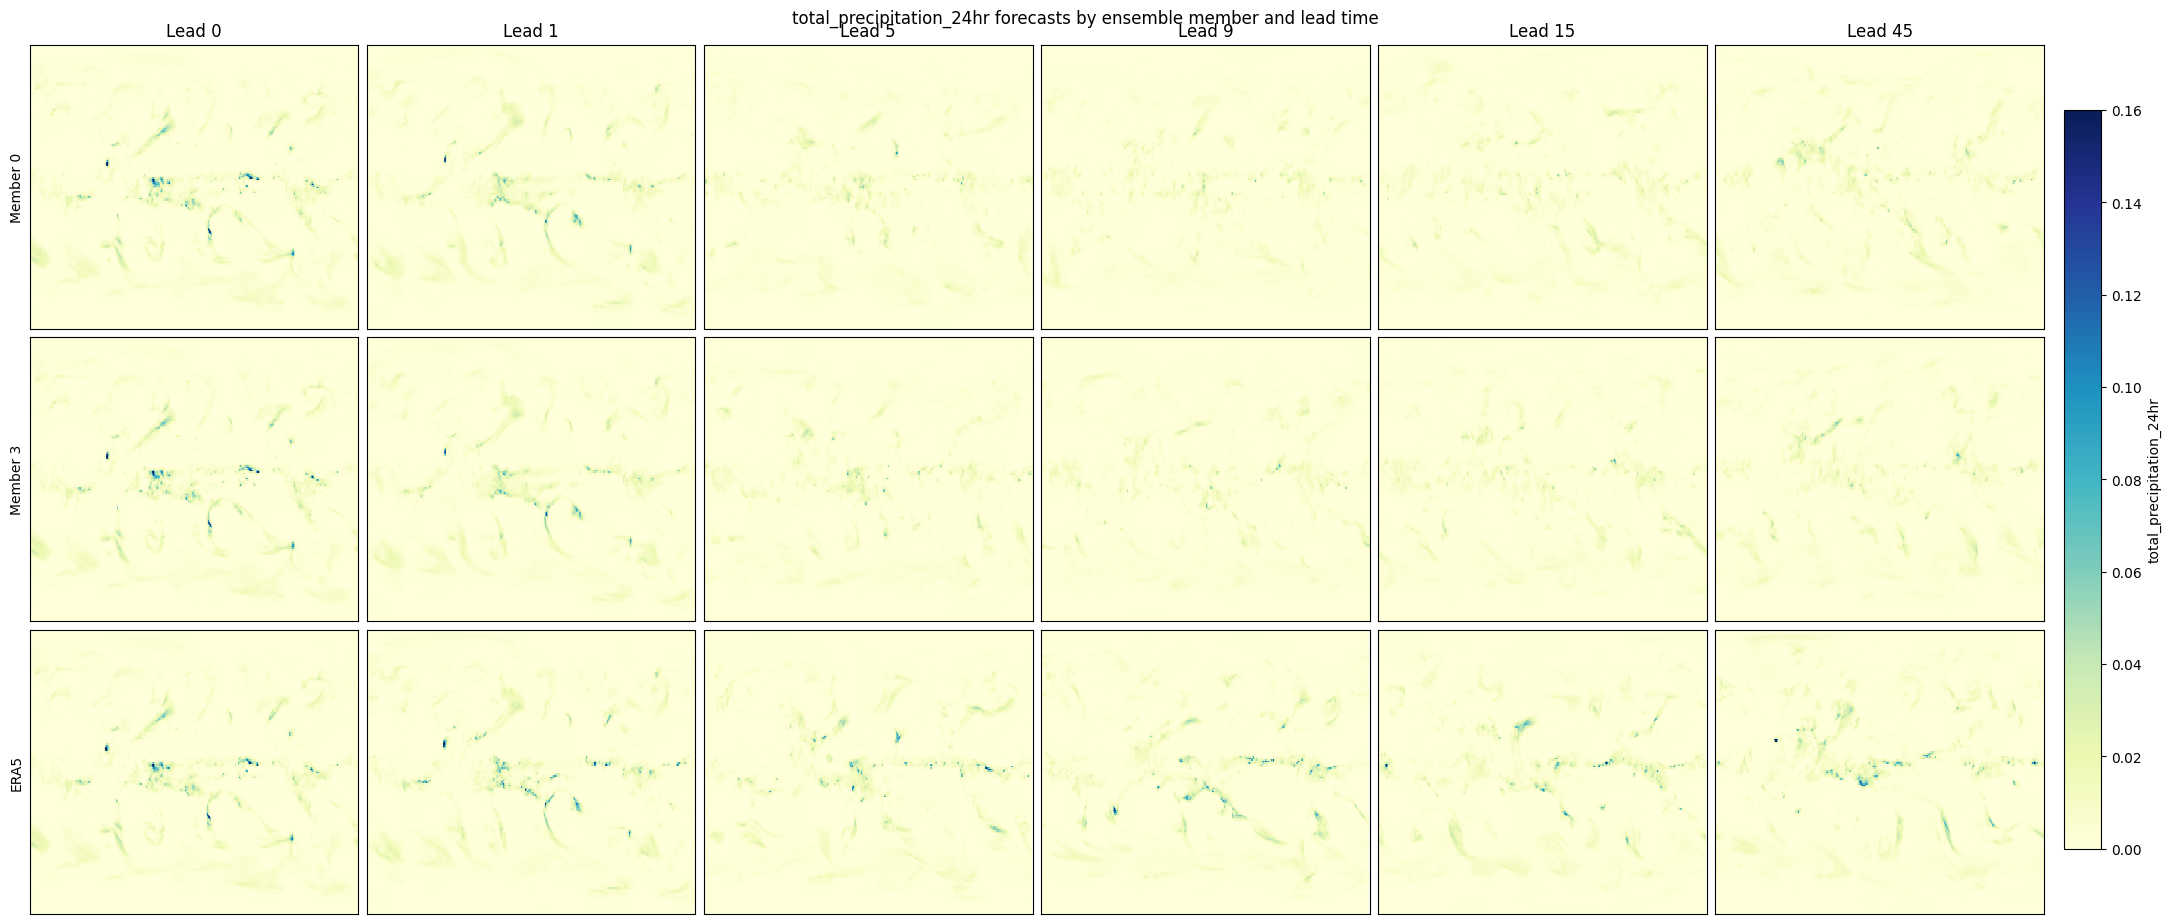

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

lead_times = [0, 1, 5, 9, 15, 45]
ensemble_members = [0,3]

fcst = dt[variable_fcst] * 24 * 3.6 if isinstance(dt, xr.Dataset) else dt
truth = era5[variable] if isinstance(era5, xr.Dataset) else era5


def find_name(obj, candidates):
    for name in obj.dims:
        if name.lower() in candidates:
            return name
    for name in obj.coords:
        if name.lower() in candidates:
            return name
    return None


lat_name = find_name(fcst, {"lat", "latitude"}) or find_name(truth, {"lat", "latitude"})
lon_name = find_name(fcst, {"lon", "longitude"}) or find_name(truth, {"lon", "longitude"})
member_name = find_name(fcst, {"member", "number", "ensemble", "ens"})
lead_name = find_name(fcst, {"time", "valid_time", "lead_time", "step", "forecast_hour"})
truth_time_name = find_name(truth, {"time", "valid_time"})

if member_name is None:
    raise ValueError(f"Could not find an ensemble dimension in forecast dims {fcst.dims}")
if lead_name is None:
    raise ValueError(f"Could not find a lead-time dimension in forecast dims {fcst.dims}")
if lat_name is None or lon_name is None:
    raise ValueError("Could not find latitude/longitude dimensions in the forecast or ERA5 data")
if truth_time_name is None:
    raise ValueError(f"Could not find a time dimension in ERA5 dims {truth.dims}")

if fcst.sizes[member_name] < 4:
    raise ValueError(f"Expected at least 4 ensemble members, found {fcst.sizes[member_name]}")
if fcst.sizes[lead_name] <= max(lead_times):
    raise ValueError(
        f"Forecast lead axis '{lead_name}' has size {fcst.sizes[lead_name]}, which is too small for lead times {lead_times}"
    )

selected_forecasts = []
selected_truths = []

for lead in lead_times:
    forecast_lead = fcst.isel({lead_name: lead}).squeeze(drop=True)
    selected_forecasts.append(forecast_lead)

    forecast_time = forecast_lead.coords.get(lead_name, None)
    if forecast_time is None:
        forecast_time = fcst[lead_name].isel({lead_name: lead}).values
    else:
        forecast_time = forecast_time.values

    truth_lead = truth.sel({truth_time_name: forecast_time}, method="nearest")
    selected_truths.append(truth_lead.squeeze(drop=True))

all_fields = []

for forecast_lead, truth_lead in zip(selected_forecasts, selected_truths):
    for member in ensemble_members:
        all_fields.append(forecast_lead.isel({member_name: member}).values)
    all_fields.append(truth_lead.values)

# vmin = np.nanmin([np.nanmin(field) for field in all_fields])
# vmax = np.nanmax([np.nanmax(field) for field in all_fields])
vmin = 0.0
vmax = 0.16

row_labels = [f"Member {m}" for m in ensemble_members] + ["ERA5"]

fig, axes = plt.subplots(
    len(ensemble_members) + 1,
    len(lead_times),
    figsize=(3.6 * len(lead_times), 3.0 * (len(ensemble_members) + 1)),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

for ax, lead in zip(axes[0], lead_times):
    ax.set_title(f"Lead {lead}")

mesh = None
for col, (lead, forecast_lead, truth_lead) in enumerate(zip(lead_times, selected_forecasts, selected_truths)):
    for row, member in enumerate(ensemble_members):
        ax = axes[row, col]
        field = forecast_lead.isel({member_name: member}).squeeze(drop=True)
        mesh = ax.pcolormesh(
            field[lon_name],
            field[lat_name],
            field,
            shading="auto",
            cmap="YlGnBu",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_labels[row])

    ax = axes[-1, col]
    mesh = ax.pcolormesh(
        truth_lead[lon_name],
        truth_lead[lat_name],
        truth_lead,
        shading="auto",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    if col == 0:
        ax.set_ylabel(row_labels[-1])

cbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), shrink=0.85, pad=0.01)
cbar.set_label(variable)
fig.suptitle(f"{variable} forecasts by ensemble member and lead time", y=1.01)
plt.show()
